# XG-Boost

## Import libraries

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd

# Data Processing and Resampling
from sklearn.utils import resample
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

# Model and Training
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Kaggle and File Handling
import kagglehub
import os
import glob

# Feature Importance (Permutation)
from sklearn.inspection import permutation_importance

## Explaining techniques applied



### XGBoost

#### What is Gradient Boosting?

XGBoost (eXtreme Gradient Boosting) is a cutting-edge machine learning algorithm that excels in structured data problems, such as classification and regression.

Gradient Boosting is an ensemble learning method that builds a predictive model incrementally by combining the strengths of multiple weak learners, typically decision trees. It works by sequentially adding new trees that correct the errors made by previous models. The process involves minimizing a loss function (e.g., mean squared error for regression or log loss for classification) by iteratively optimizing the predictions.

Key steps in gradient boosting:
1. **Initialization**: Start with a simple model, such as predicting the mean of the target values.
2. **Residual Calculation**: Calculate the residuals (errors) between the current predictions and actual values.
3. **New Model**: Train a new model to predict the residuals.
4. **Update**: Add the new model's predictions to the previous model, gradually improving accuracy.
5. **Repeat**: Continue adding models until a stopping criterion, such as a maximum number of iterations or a negligible improvement, is met.

Gradient boosting's strength lies in its ability to optimize complex objective functions and handle both regression and classification tasks effectively.

#### How XGBoost Enhances Gradient Boosting

XGBoost builds on the foundation of gradient boosting by introducing several key enhancements:
1. **Regularization**: XGBoost incorporates L1 (Lasso) and L2 (Ridge) regularization to reduce overfitting, making it more robust on complex datasets.
2. **Efficient Computations**: It uses optimized data structures and algorithms, such as parallel processing and in-memory computations, to handle large datasets with remarkable speed.
3. **Sparsity Awareness**: Automatically handles missing or sparse data by learning optimal split directions.
4. **Flexibility**: Supports custom objective functions and evaluation metrics, catering to a wide range of use cases.
5. **Advanced Tree Pruning**: Employs a "max delta step" algorithm for better handling of imbalanced data.

#### Why Use XGBoost?

XGBoost is widely regarded for its superior predictive accuracy and efficiency. It consistently outperforms other machine learning algorithms in tasks involving tabular data. It has also gained immense popularity in data science competitions like Kaggle, where small performance gains can make a significant difference.

#### Benefits of XGBoost

- Handles large datasets with high performance.
- Offers fine-grained control over model parameters.
- Supports distributed computing for scalability.
- Can be used for classification and regression.

#### Model Explanation

##### Simple Explanation

To put it in a way that a person without mathematical background can understand, XGBoost is a machine learning algorithm that builds a series of simple decision trees, each focusing on correcting the mistakes of the previous ones. It starts with a basic prediction (like guessing the average value) and measures the errors. Then, it creates a tree to learn patterns in those errors and updates the predictions by combining the original guess with the tree's corrections. This process is repeated step by step, gradually improving accuracy. XGBoost also includes safeguards to prevent overfitting by limiting tree complexity and adding penalties for overly complicated models, making it fast, efficient, and highly effective for many types of data.

##### Mathematical Explanation

###### Objective Function

XGBoost optimizes an objective function that combines a loss function and a regularization term:
$$
\mathcal{L}\left(F_m\right)=\sum_{i=1}^N L\left(y_i, \hat{y}_i\right)+\Omega\left(f_m\right)
$$

Where:
- $L\left(y_i, \hat{y}_i\right)$ : A differentiable convex loss function (e.g., mean squared error for regression, log-loss for classification).
- $\hat{y}_i=F_m\left(x_i\right)$ : The predicted value for sample $i$.
- $\Omega\left(f_m\right)$ : Regularization term for the complexity of the current tree $f_m(x)$.


####### Regularization Term

The regularization term controls the complexity of the tree:
$$
\Omega\left(f_m\right)=\gamma T+\frac{1}{2} \lambda \sum_{j=1}^T w_j^2
$$

Where:
- $T$ : Number of leaves in the tree.
- $w_j$ : The weight of the $j$-th leaf.
- $\gamma$ : Minimum loss reduction required to make a split.
- $\quad \lambda$ : L2 regularization term on leaf weights.

###### Second-Order Approximation for Efficiency


To make optimization tractable, XGBoost uses a second-order Taylor expansion of the loss function around the current prediction $F_{m-1}(x)$ :
$$
L\left(y_i, F_m\left(x_i\right)\right) \approx L\left(y_i, F_{m-1}\left(x_i\right)\right)+g_i f_m\left(x_i\right)+\frac{1}{2} h_i\left[f_m\left(x_i\right)\right]^2
$$

Where:
- $g_i=\frac{\partial L\left(y_i, F\left(x_i\right)\right)}{\partial F\left(x_i\right)}:$ First derivative (gradient).
- $h_i=\frac{\partial^2 L\left(y_i, F\left(x_i\right)\right)}{\partial^2 F\left(x_i\right)}$ : Second derivative (Hessian).

Substituting this into the objective function:
$$
\mathcal{L}\left(F_m\right) \approx \sum_{i=1}^N\left[g_i f_m\left(x_i\right)+\frac{1}{2} h_i f_m^2\left(x_i\right)\right]+\Omega\left(f_m\right)
$$

This approximation makes it possible to optimize each tree efficiently.

###### Tree Structure

XGBoost builds decision trees $f_m(x)$, where each tree maps an input $x$ to a leaf node weight $w_j$. The structure of the tree is defined by partitioning the data into regions $R_j$, so the prediction for $x \in R_j$ is:
$$
f_m(x)=w_j \quad \text { if } \quad x \in R_j
$$

The goal is to find the optimal $w_j$ and splits $R_j$ to minimize the objective function.

###### Optimizing Leaf Weights



For a given structure of the tree, the optimal weight $w_j$ for a leaf $j$ is computed as:
$$
w_j^*=-\frac{\sum_{i \in R_j} g_i}{\sum_{i \in R_j} h_i+\lambda}
$$

Where:
- $\sum_{i \in R_j} g_i$ : Sum of gradients for samples in leaf $j$.
- $\sum_{i \in R_j} h_i$ : Sum of Hessians for samples in leaf $j$.
- $\lambda$ : L2 regularization parameter.


###### Tree Splitting Criterion



The quality of a split is evaluated using the gain, which measures the improvement in the objective function. For a split into two regions $R_L$ and $R_R$ :
$$
\text { Gain }=\frac{1}{2}\left[\frac{\left(\sum_{i \in R_L} g_i\right)^2}{\sum_{i \in R_L} h_i+\lambda}+\frac{\left(\sum_{i \in R_R} g_i\right)^2}{\sum_{i \in R_R} h_i+\lambda}-\frac{\left(\sum_{i \in R} g_i\right)^2}{\sum_{i \in R} h_i+\lambda}\right]-\gamma
$$

Where:
- $R$ : The region before the split.
- $\gamma$ : Regularization term for tree complexity.

The split with the highest gain is chosen.

###### Prediction Update

After building the $m$-th tree, the model is updated as:
$$
F_m(x)=F_{m-1}(x)+\nu f_m(x)
$$

Where $\nu$ is the learning rate.

## SMOTE

#### Quick explanation

SMOTE (Synthetic Minority Over-sampling Technique) is a method used to solve the problem of imbalanced datasets in machine learning. When one class in a dataset has fewer examples than the other, SMOTE creates new, synthetic data points for the underrepresented class. It does this by picking random points between an existing minority class sample and its neighbors, then generating new data points along the way. This helps balance the dataset, allowing the model to learn better from the minority class and improve performance, especially in predicting rare events. However, it can also introduce noise if the original data is not clean.

#### Example

Class distribution before SMOTE: Counter({0: 744, 1: 256})
Class distribution after SMOTE: Counter({0: 744, 1: 744})


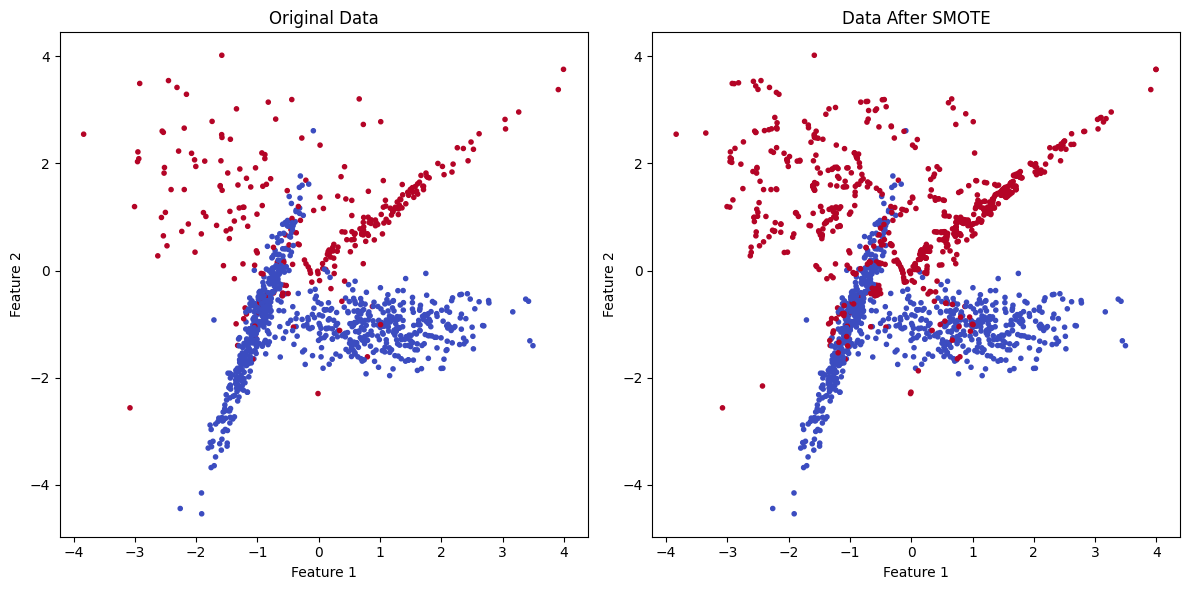

In [ ]:
# Generate an imbalanced dataset with a 75-25 distribution
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, weights=[0.75, 0.25], random_state=42)

# Before applying SMOTE: Show class distribution
print("Class distribution before SMOTE:", Counter(y))

# Apply SMOTE to balance the classes
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# After applying SMOTE: Show new class distribution
print("Class distribution after SMOTE:", Counter(y_res))

# Plotting the data before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot original data
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', marker='.')
axes[0].set_title("Original Data")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Plot resampled data
axes[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', marker='.')
axes[1].set_title("Data After SMOTE")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

*   Class distribution before SMOTE: You'll see that the majority class (0) makes up 75% of the data, and the minority class (1) makes up 25%.
*   Class distribution after SMOTE: The minority class will be upsampled to match the majority class, achieving a balanced dataset with a 50-50 distribution of classes.
*   Visualization: The plot will show the original imbalanced data and the new synthetic data points generated by SMOTE for the minority class.

This will balance the class distribution to 50-50 after applying SMOTE and help in addressing the class imbalance for better model performance.

## Downsampling

#### Quick explanation

Downsampling is the technique of reducing the number of instances in the majority class to balance the dataset. By doing so, the model won't be biased toward the majority class and will have a better chance of learning to predict the minority class.

#### Example

Original class distribution: Target
0.0    800
1.0    200
Name: count, dtype: int64
New class distribution after downsampling: Target
0.0    300
1.0    200
Name: count, dtype: int64


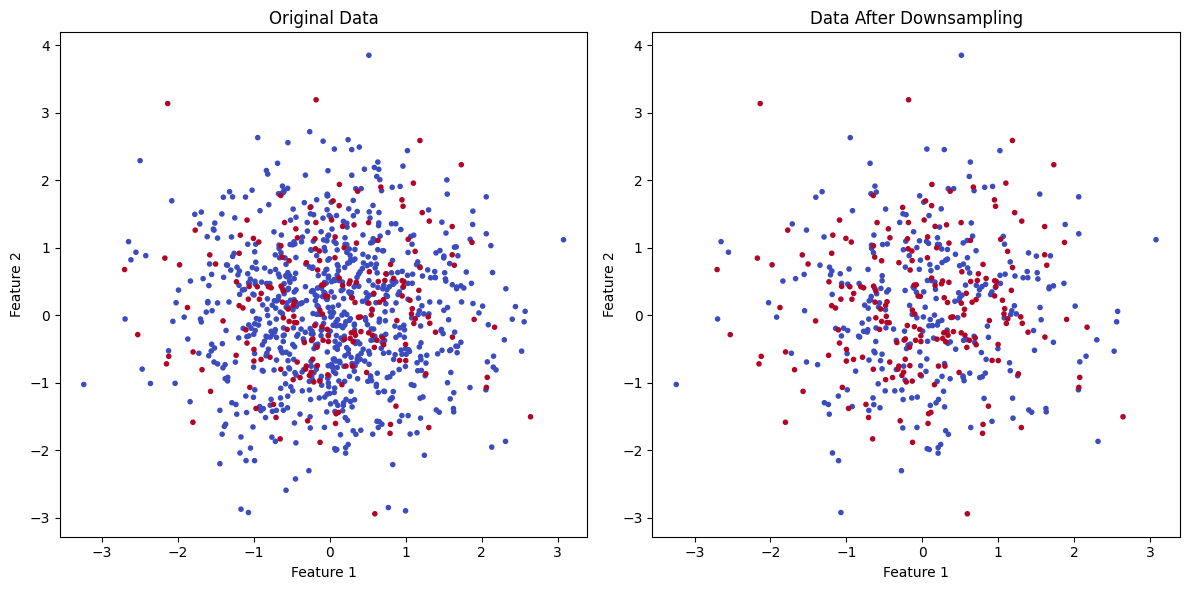

In [ ]:
# Create a synthetic dataset with imbalanced classes
np.random.seed(42)
n_samples = 1000
majority_class_size = 800
minority_class_size = 200

# Majority class (Class 0)
X_majority = np.random.randn(majority_class_size, 2)
y_majority = np.zeros(majority_class_size)

# Minority class (Class 1)
X_minority = np.random.randn(minority_class_size, 2)
y_minority = np.ones(minority_class_size)

# Combine majority and minority class into one dataset
X = np.vstack((X_majority, X_minority))
y = np.hstack((y_majority, y_minority))

# Create a DataFrame for convenience
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Target'] = y

# Show original class distribution
print("Original class distribution:", df['Target'].value_counts())

# Separate majority and minority classes
majority_class = df[df['Target'] == 0]
minority_class = df[df['Target'] == 1]

# Downsample the majority class
downsampled_majority_size = min(int(1.5 * len(minority_class)), len(majority_class))

majority_downsampled = resample(
    majority_class,
    replace=False,  # No replacement
    n_samples=downsampled_majority_size,  # Downsample size
    random_state=42
)

# Combine the downsampled majority class with the minority class
downsampled_data = pd.concat([majority_downsampled, minority_class])

# Show new class distribution
print("New class distribution after downsampling:", downsampled_data['Target'].value_counts())

# Plot the data before and after downsampling
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot original data
axes[0].scatter(df['Feature1'], df['Feature2'], c=df['Target'], cmap='coolwarm', marker='.')
axes[0].set_title("Original Data")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Plot downsampled data
axes[1].scatter(downsampled_data['Feature1'], downsampled_data['Feature2'], c=downsampled_data['Target'], cmap='coolwarm', marker='.')
axes[1].set_title("Data After Downsampling")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()



*   Original Distribution: The original dataset will have a 4:1 ratio (80% majority and 20% minority).
*   New Distribution: After downsampling, the dataset will have a more balanced distribution, closer to 50:50.

## XGBoost on Raw Data

### Import data

In [ ]:
anhphanmancity_eeg_data_path = kagglehub.dataset_download('anhphanmancity/eeg-data')

print('Data source import complete.')

100%|██████████| 867M/867M [00:13<00:00, 66.0MB/s]

Extracting files...


Data source import complete.


In [ ]:
!ls $anhphanmancity_eeg_data_path

subject_10.csv	subject_14.csv	subject_20.csv	subject_26.csv	subject_32.csv	subject_4.csv
subject_11.csv	subject_17.csv	subject_21.csv	subject_27.csv	subject_33.csv	subject_5.csv
subject_12.csv	subject_18.csv	subject_24.csv	subject_28.csv	subject_34.csv	subject_6.csv
subject_13.csv	subject_19.csv	subject_25.csv	subject_31.csv	subject_3.csv	subject_7.csv


In [ ]:
# Path to your directory (set your path here)
directory_path = anhphanmancity_eeg_data_path

# Use glob to get all CSV files in the directory
file_paths = glob.glob(f"{directory_path}/*.csv")

### Define necessary functions

In [ ]:
# Sliding window function
def sliding_window(data, label):
    X = pd.DataFrame()
    y = pd.DataFrame()
    data = data.drop('state', axis=1)
    for channel in data.columns:
        rolling = data[channel].rolling(20).mean()
        X[channel] = rolling
    X = X.dropna()
    y = label[:len(X)].reset_index(drop=True)
    return X, y

In [ ]:
# Process sliding window
def process_sliding_window(dataset, sliding_window):
    X = pd.DataFrame()
    y = pd.DataFrame()
    start = 0
    mapping = {1: 0, 2: 1, 0: 2}
    dataset['state'] = dataset['state'].map(mapping)
    dataset = dataset.drop(['AF3', 'AF4'], axis=1, errors='ignore')  # Handle missing columns
    for state in dataset['state'].unique():
        end = start + np.sum(dataset['state'] == state)
        X_label, y_label = sliding_window(dataset[start:end], dataset['state'][start:end])
        X = pd.concat([X, X_label], ignore_index=True)
        y = pd.concat([y, y_label], ignore_index=True)
        start = end
    return X, y

In [ ]:
# Sampling function
def sampling_data(data):
    stratified_sample = data.groupby('state', group_keys=False, dropna=False).apply(
        lambda x: x.sample(frac=0.01, random_state=42)
    )
    return stratified_sample.reset_index(drop=True)

### Store data

In [ ]:
# Initialize empty DataFrames to store processed data
X = pd.DataFrame()
y = pd.DataFrame()

In [ ]:
# Process all files using the Colab-compatible approach
for path in file_paths:
    data = pd.read_csv(path)  # Read each CSV file
    stratified_sample = sampling_data(data)  # Apply sampling
    X_sample, y_sample = process_sliding_window(stratified_sample, sliding_window)  # Apply sliding window
    X = pd.concat([X, X_sample], ignore_index=True)
    y = pd.concat([y, y_sample], ignore_index=True)

<ipython-input-9-2e69d3fd6fdc>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = data.groupby('state', group_keys=False, dropna=False).apply(
<ipython-input-9-2e69d3fd6fdc>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = data.groupby('state', group_keys=False, dropna=False).apply(
<ipython-input-9-2e69d3fd6fdc>:3: DeprecationWarning: DataFrameGroupBy.apply operated on

In [ ]:
# Features and target extraction for the final processed data
final_X = X  # Features
final_y = y  # Target variable

In [ ]:
# Display results
print("Processed Features (X):")
print(final_X.head())

print("\nProcessed Target (y):")
print(final_y.head())

Processed Features (X):
             F7             F3            FC5            T7            P7  \
0  8.822099e+05  456212.333851  195762.930370  4.089811e+05  3.260532e+06   
1  6.954385e+05  431423.136666  192309.335865  4.785997e+05  2.821032e+06   
2  5.102635e+05  190011.879361   38896.913425  9.028818e+05  2.615484e+06   
3  1.051151e+06  125405.141150 -175098.503486  1.112547e+06  1.685674e+06   
4  1.031279e+06 -337467.642642 -626222.325498  1.010744e+06  8.807240e+05   

             O1            O2            P8             T8            FC6  \
0  3.943551e+06  4.498052e+05 -2.511906e+06 -562033.977549  400889.038206   
1  3.301278e+06  1.478284e+05 -2.302999e+06 -496878.413468  286890.912383   
2  2.612377e+06 -8.556301e+04 -2.088083e+06 -238017.894988  436741.363242   
3  1.748125e+06 -8.002119e+05 -2.641484e+06 -470689.135677  327097.069347   
4  1.390886e+06 -1.702554e+06 -3.148507e+06 -695290.881784  112188.411783   

              F4            F8  
0 -245108.986092 

In [ ]:
print(X.shape, y.shape)

(68043, 12) (68043, 1)


### Basic information about data

In [ ]:
# Ensure y is a single-column DataFrame and convert it to a Series
if isinstance(y, pd.DataFrame) and y.shape[1] == 1:
    y = pd.Series(y.iloc[:, 0].values, name='state')  # Extract the first column as a Series
elif not isinstance(y, pd.Series):
    y = pd.Series(y, name='state')  # Convert to Series if it's not already one
else:
    y = y.rename('state')  # Rename if it's already a Series

# Combine X and y into a single DataFrame
combined_data = pd.concat([X, y], axis=1)

In [ ]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68043 entries, 0 to 68042
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F7      68043 non-null  float64
 1   F3      68043 non-null  float64
 2   FC5     68043 non-null  float64
 3   T7      68043 non-null  float64
 4   P7      68043 non-null  float64
 5   O1      68043 non-null  float64
 6   O2      68043 non-null  float64
 7   P8      68043 non-null  float64
 8   T8      68043 non-null  float64
 9   FC6     68043 non-null  float64
 10  F4      68043 non-null  float64
 11  F8      68043 non-null  float64
 12  state   68043 non-null  float64
dtypes: float64(13)
memory usage: 6.7 MB


In [ ]:
combined_data.head()

,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,state
0,8.822099e+05,456212.333851,195762.930370,4.089811e+05,3.260532e+06,3.943551e+06,4.498052e+05,-2.511906e+06,-562033.977549,400889.038206,-245108.986092,-45004.648002,2.0
1,6.954385e+05,431423.136666,192309.335865,4.785997e+05,2.821032e+06,3.301278e+06,1.478284e+05,-2.302999e+06,-496878.413468,286890.912383,-310149.239314,-78541.640607,2.0
2,5.102635e+05,190011.879361,38896.913425,9.028818e+05,2.615484e+06,2.612377e+06,-8.556301e+04,-2.088083e+06,-238017.894988,436741.363242,-440647.973144,-13917.719627,2.0
3,1.051151e+06,125405.141150,-175098.503486,1.112547e+06,1.685674e+06,1.748125e+06,-8.002119e+05,-2.641484e+06,-470689.135677,327097.069347,-419480.652782,-585.783887,2.0
4,1.031279e+06,-337467.642642,-626222.325498,1.010744e+06,8.807240e+05,1.390886e+06,-1.702554e+06,-3.148507e+06,-695290.881784,112188.411783,-282833.509023,-23312.416921,2.0


In [ ]:
combined_data.describe()

,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,state
count,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,6.804300e+04,68043.000000
mean,2.381873e+04,-2.146757e+04,3.145085e+03,1.521646e+04,-3.598779e+03,6.151961e+04,5.486314e+04,-1.735498e+04,-1.434843e+03,9.904996e+03,-6.035575e+02,-3.191649e+03,1.208251
std,1.526615e+06,1.094197e+06,4.573696e+05,5.303628e+05,2.080027e+06,3.201071e+06,3.081966e+06,2.285712e+06,5.327573e+05,5.043806e+05,3.614190e+05,3.832895e+05,0.832625
min,-1.268858e+07,-7.015482e+06,-4.799467e+06,-5.631211e+06,-1.238903e+07,-1.806526e+07,-1.452194e+07,-1.327686e+07,-3.333463e+06,-5.510886e+06,-2.247826e+06,-3.430706e+06,0.000000
25%,-7.534147e+05,-5.700151e+05,-2.181610e+05,-2.314854e+05,-1.194815e+06,-1.822373e+06,-1.689310e+06,-1.311096e+06,-2.876816e+05,-1.510604e+05,-1.828343e+05,-1.826465e+05,0.000000
50%,2.327051e+04,-1.787282e+04,5.258504e+03,9.621510e+03,-1.355144e+04,-1.016784e+03,-5.959936e+03,-2.005017e+04,-1.350774e+04,1.731428e+03,-4.849292e+02,2.329826e+03,1.000000
75%,8.297868e+05,5.266135e+05,2.309434e+05,2.542224e+05,1.176211e+06,1.909148e+06,1.746632e+06,1.274088e+06,2.783373e+05,1.620728e+05,1.798095e+05,1.828407e+05,2.000000
max,9.076918e+06,1.650307e+07,3.685124e+06,5.379802e+06,1.719183e+07,2.404136e+07,2.288852e+07,1.512509e+07,4.007266e+06,6.673451e+06,4.891215e+06,3.107037e+06,2.000000


### Apply downsampling and SMOTE for balancing data

#### Downsampling

In [ ]:
# Separate majority and minority classes
majority_class = combined_data[combined_data['state'] == 0.0]
minority_classes = combined_data[combined_data['state'] != 0.0]

# Determine 1.5x the largest minority class size
largest_minority_class_size = minority_classes['state'].value_counts().max()

# Ensure downsample size is not larger than available majority class size
downsampled_majority_size = min(int(1.5 * largest_minority_class_size), len(majority_class))

# Downsample the majority class
majority_downsampled = resample(
    majority_class,
    replace=False,  # Sampling without replacement
    n_samples=downsampled_majority_size,
    random_state=42
)

# Combine the downsampled majority class with minority classes
downsampled_data = pd.concat([majority_downsampled, minority_classes])

# Split features and target again
X_downsampled = downsampled_data.drop(columns=['state'])
y_downsampled = downsampled_data['state']

# Print class distribution after downsampling
print("Class distribution after downsampling:", Counter(y_downsampled))

Class distribution after downsampling: Counter({2.0: 32146, 0.0: 17976, 1.0: 17921})


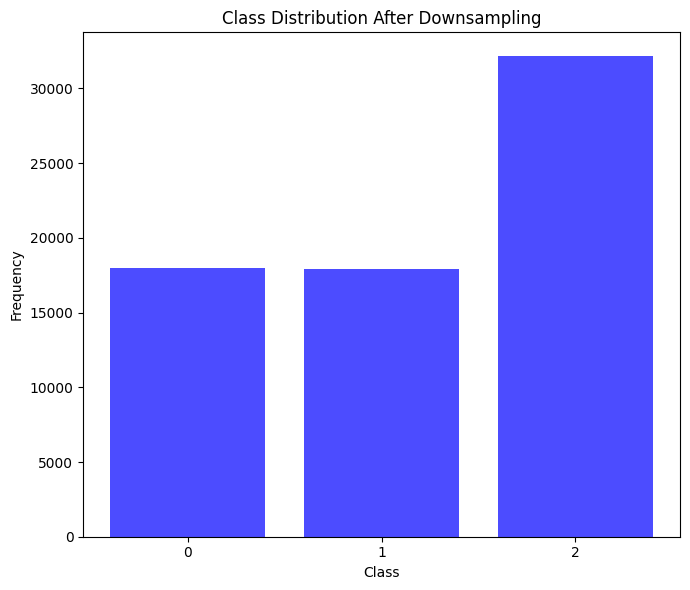

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Class distribution after downsampling
class_dist_downsampling = Counter({2.0: 32146, 0.0: 17976, 1.0: 17921})

# Plot the histogram for class distribution after downsampling
plt.figure(figsize=(7, 6))
plt.bar(class_dist_downsampling.keys(), class_dist_downsampling.values(), color='blue', alpha=0.7)
plt.title('Class Distribution After Downsampling')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(list(class_dist_downsampling.keys()))
plt.tight_layout()
plt.show()


#### SMOTE

In [ ]:
# Apply SMOTE on the downsampled dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_downsampled, y_downsampled)

# Print class distribution after SMOTE
print("Class distribution after SMOTE:", Counter(y_resampled))

Class distribution after SMOTE: Counter({0.0: 32146, 2.0: 32146, 1.0: 32146})


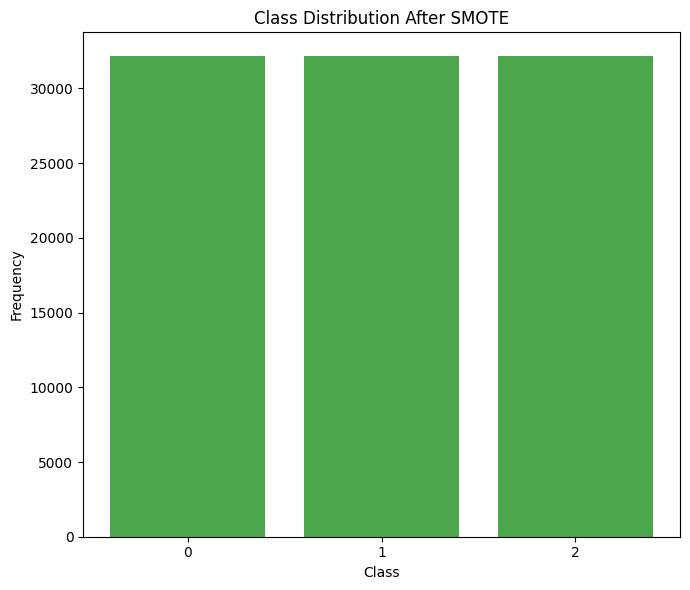

In [ ]:
# Class distribution after applying SMOTE
class_dist_smote = Counter({0.0: 32146, 2.0: 32146, 1.0: 32146})

# Plot the histogram for class distribution after SMOTE
plt.figure(figsize=(7, 6))
plt.bar(class_dist_smote.keys(), class_dist_smote.values(), color='green', alpha=0.7)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(list(class_dist_smote.keys()))
plt.tight_layout()
plt.show()

In [ ]:
# Combine resampled features and target into a single DataFrame if needed
resampled_data = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=['state'])], axis=1)

# Print the final resampled data
print(resampled_data.head())

             F7            F3            FC5            T7            P7  \
0 -1.114944e+06  7.800167e+05 -119470.564770 -1.812373e+05  1.688520e+05   
1 -3.690410e+05 -4.306844e+05 -138768.976028  1.679965e+05 -2.370645e+06   
2 -4.951554e+05 -3.720053e+05  403964.448126  1.113711e+06  1.988450e+05   
3  2.169985e+06  7.675395e+05  469961.191414 -1.024831e+05 -1.575372e+06   
4  1.117321e+06 -1.139467e+06   -9636.484402  1.441366e+05 -2.423259e+06   

             O1            O2            P8             T8            FC6  \
0  2.291015e+06  7.860301e+05  2.652605e+06  398476.346944  -37078.903761   
1 -3.642295e+06 -4.586840e+06 -1.590212e+06 -155833.858753   72554.795117   
2 -2.349653e+06 -3.585945e+06 -5.348533e+05  -54250.236226 -138489.796909   
3 -1.222349e+06  1.227791e+06  1.668138e+06    -801.760126  132736.842244   
4 -4.486034e+06 -4.985442e+06 -3.092697e+06 -280862.708821   38388.405334   

              F4             F8  state  
0 -294435.415670 -437474.233506    0.0 

### Split data

In [ ]:
# Split into 80% training/validation and 20% test based on 'state'
train_val, test = train_test_split(
    resampled_data, test_size=0.2, stratify=resampled_data['state'], random_state=42
)

# Further split training/validation into 80% training and 20% validation
train, val = train_test_split(
    train_val, test_size=0.2, stratify=train_val['state'], random_state=42
)

# Verify the splits
train_percentage = len(train) / len(resampled_data) * 100
val_percentage = len(val) / len(resampled_data) * 100
test_percentage = len(test) / len(resampled_data) * 100

print(f"Train: {len(train)} ({train_percentage:.2f}%)")
print(f"Validation: {len(val)} ({val_percentage:.2f}%)")
print(f"Test: {len(test)} ({test_percentage:.2f}%)")

Train: 61720 (64.00%)
Validation: 15430 (16.00%)
Test: 19288 (20.00%)


In [ ]:
# Prepare Features and Target
X_train = train.drop(columns=['state'])
y_train = train['state']

X_val = val.drop(columns=['state'])
y_val = val['state']

X_test = test.drop(columns=['state'])
y_test = test['state']

### Train model

The following model is configured for robust multi-class classification with mechanisms to prevent overfitting (`subsample`, `colsample_bytree`, `early_stopping_rounds`), while ensuring sufficient flexibility to learn from the data (`learning_rate`, `max_depth`). The high `n_estimators` ensures adequate boosting rounds, with early stopping to halt training when the performance plateaus.

In [ ]:
# Define the XGBoost model
model = XGBClassifier(
    objective="multi:softmax",  # Objective function for multi-class classification
    num_class=data['state'].nunique(),  # Number of unique classes in the target
    learning_rate=0.05,         # Learning rate for gradient boosting
    n_estimators=3000,          # Maximum number of boosting iterations
    max_depth=4,                # Maximum depth of each tree
    subsample=0.8,              # Fraction of samples used for training each tree
    colsample_bytree=0.8,       # Fraction of features used for training each tree
    early_stopping_rounds=100,  # Stops training if validation score doesn't improve
    random_state=42,            # For reproducibility
    verbosity=1                 # Controls the level of output during training
)

**General Parameters**

- **`objective="multi:softmax"`**:
  - Specifies the task the model is solving.
  - `"multi:softmax"` means the model will perform multi-class classification and output the predicted class directly (as opposed to probabilities).
  
- **`num_class=data['state'].nunique()`**:
  - Specifies the number of unique classes in the target variable (`data['state']`).
  - This is required for multi-class classification.

- **`random_state=42`**:
  - Sets a seed for random number generation, ensuring reproducibility of results.
  - Using the same seed will always yield the same results.

- **`verbosity=1`**:
  - Controls the level of logs printed during training.
  - `0` = silent, `1` = shows progress, `2` = shows detailed logs.

**Optimization Parameters**

- **`learning_rate=0.05`**:
  - Step size for updating model weights during optimization.
  - A smaller learning rate makes training slower but can improve performance by preventing the model from overshooting the optimal solution.

- **`n_estimators=3000`**:
  - Maximum number of boosting rounds (trees) the model will train.
  - The actual number of iterations may be less if `early_stopping_rounds` is triggered.

**Tree Parameters**

- **`max_depth=4`**:
  - Maximum depth of each decision tree.
  - Controls model complexity and prevents overfitting.
  - Smaller values reduce overfitting but may underfit; larger values increase complexity.

- **`subsample=0.8`**:
  - Fraction of the training data used for each boosting iteration.
  - Helps prevent overfitting by introducing randomness (only 80% of the data is used in each tree).

- **`colsample_bytree=0.8`**:
  - Fraction of features (columns) used for each tree.
  - Adds randomness by using only 80% of features during training.

**Early Stopping**

- **`early_stopping_rounds=100`**:
  - Stops training if the validation score doesn’t improve for 100 consecutive rounds.
  - Prevents overfitting and saves computational resources.

In [ ]:
# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],  # Training and validation sets
    verbose=50  # Log progress every 50 rounds
)

[0]	validation_0-mlogloss:1.09654	validation_1-mlogloss:1.09668
[50]	validation_0-mlogloss:1.04025	validation_1-mlogloss:1.04498
[100]	validation_0-mlogloss:1.01117	validation_1-mlogloss:1.01976
[150]	validation_0-mlogloss:0.98995	validation_1-mlogloss:1.00194
[200]	validation_0-mlogloss:0.97117	validation_1-mlogloss:0.98632
[250]	validation_0-mlogloss:0.95451	validation_1-mlogloss:0.97264
[300]	validation_0-mlogloss:0.93890	validation_1-mlogloss:0.96030
[350]	validation_0-mlogloss:0.92534	validation_1-mlogloss:0.94995
[400]	validation_0-mlogloss:0.91197	validation_1-mlogloss:0.93991
[450]	validation_0-mlogloss:0.89951	validation_1-mlogloss:0.93039
[500]	validation_0-mlogloss:0.88755	validation_1-mlogloss:0.92140
[550]	validation_0-mlogloss:0.87567	validation_1-mlogloss:0.91272
[600]	validation_0-mlogloss:0.86428	validation_1-mlogloss:0.90404
[650]	validation_0-mlogloss:0.85357	validation_1-mlogloss:0.89625
[700]	validation_0-mlogloss:0.84366	validation_1-mlogloss:0.88902
[750]	validat

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=3000, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

The reported values (e.g., validation_0-mlogloss and validation_1-mlogloss) correspond to the multi-class logarithmic loss (log-loss): validation_0 refers to the training data performance, while validation_1 refers to the validation data performance.

Log-loss measures the model's uncertainty in predictions. Lower values indicate better performance. It penalizes incorrect predictions more severely when the model is confident about the wrong class.

Loss Trends

*   Training Loss (validation_0-mlogloss):

The training loss steadily decreases as the model continues to learn from the data. This shows that the model is capturing patterns in the training dataset effectively.

*   Validation Loss (validation_1-mlogloss):

The validation loss decreases initially and closely tracks the training loss.

As training progresses, validation loss also continues to decrease without divergence, which suggests no significant overfitting.

Key Observations

Validation loss (0.70741) at the final iteration is slightly higher than the training loss (0.57065). This is a good sign because:

- It indicates the model hasn't overfit to the training data.
- A slight gap between training and validation loss is expected.

The consistent decline in validation loss shows the model effectively learns patterns in the validation set, suggesting a well-generalized model.

### Model evaluation

In [ ]:
# Evaluate the model
# Validation
y_val_pred = model.predict(X_val)  # Predict classes for validation data
val_accuracy = accuracy_score(y_val, y_val_pred)  # Calculate accuracy
print(f"Validation Accuracy: {val_accuracy:.2f}")

# Test
y_test_pred = model.predict(X_test)  # Predict classes for test data
test_accuracy = accuracy_score(y_test, y_test_pred)  # Calculate accuracy
print(f"Test Accuracy: {test_accuracy:.2f}")

Validation Accuracy: 0.71
Test Accuracy: 0.71


In [ ]:
# Predict probabilities
y_hat = model.predict_proba(X_test)  # Predict probabilities for each class

# Convert probabilities to class labels
y_hat_classes = np.argmax(y_hat, axis=1)

# One-hot encode the labels for AUC calculation
n_classes = y_hat.shape[1]  # Number of classes
y_test_one_hot = label_binarize(y_test, classes=range(n_classes))

# Calculate AUC (OvR strategy)
auc_scores = roc_auc_score(y_test_one_hot, y_hat, average=None, multi_class='ovr')
macro_auc = roc_auc_score(y_test_one_hot, y_hat, average='macro', multi_class='ovr')

# Print evaluation metrics
print('Evaluation on test set:')
print(classification_report(y_test, y_hat_classes))
print(f'Class-wise AUC scores: {auc_scores}')
print(f'Macro-average AUC: {macro_auc}')

Evaluation on test set:
              precision    recall  f1-score   support

         0.0       0.72      0.74      0.73      6429
         1.0       0.70      0.73      0.72      6429
         2.0       0.70      0.66      0.68      6430

    accuracy                           0.71     19288
   macro avg       0.71      0.71      0.71     19288
weighted avg       0.71      0.71      0.71     19288

Class-wise AUC scores: [0.88997282 0.88548192 0.85797797]
Macro-average AUC: 0.8778109002682642


Metrics Explained:
1. **Precision**:
   - The ratio of true positive predictions to the total predicted positives (true positives + false positives).
   - A high precision indicates fewer false positives.

2. **Recall**:
   - The ratio of true positives to the total actual positives (true positives + false negatives).
   - A high recall indicates fewer false negatives.

3. **F1-Score**:
   - The harmonic mean of precision and recall.
   - Balances precision and recall and is particularly useful when the dataset is imbalanced.

4. **Support**:
   - The number of actual occurrences of each class in the dataset.

5. **Accuracy**:
   - The proportion of correctly predicted instances out of the total instances.

6. **Macro Average**:
   - An unweighted average across all classes for precision, recall, and F1-score.
   - Treats all classes equally, regardless of support.

7. **Weighted Average**:
   - A weighted average of precision, recall, and F1-score, taking into account the support of each class.

8. **Class-wise AUC Scores**:
   - The Area Under the Curve (AUC) score for each class, showing how well the model separates positive and negative instances for that specific class.

9. **Macro-average AUC**:
   - The average of the AUC scores for all classes, treating each class equally.


Details in Your Table:

- **Class-specific metrics (0.0, 1.0, 2.0)**:
   - **Class 0.0**: Precision = 0.72, Recall = 0.74, F1-score = 0.73
   - **Class 1.0**: Precision = 0.70, Recall = 0.73, F1-score = 0.72
   - **Class 2.0**: Precision = 0.70, Recall = 0.66, F1-score = 0.68

- **Overall Performance**:
   - **Accuracy**: 71% of predictions are correct.
   - **Macro Average**: Precision, Recall, and F1-score are all around 0.71, treating all classes equally.
   - **Weighted Average**: Similar to macro average but accounts for class imbalances (weights based on support).

- **AUC Scores**:
   - Class-wise AUC scores are relatively high (0.8899, 0.8855, 0.8579), showing good separation capability.
   - Macro-average AUC: 0.8778 indicates strong overall performance.


Observations:
1. The model performs relatively well across all three classes, with precision, recall, and F1-scores close to 0.7.
2. Class 2.0 has the lowest recall (0.66) and F1-score (0.68), indicating potential room for improvement in identifying instances of this class.
3. The AUC scores suggest the model performs well in distinguishing classes.

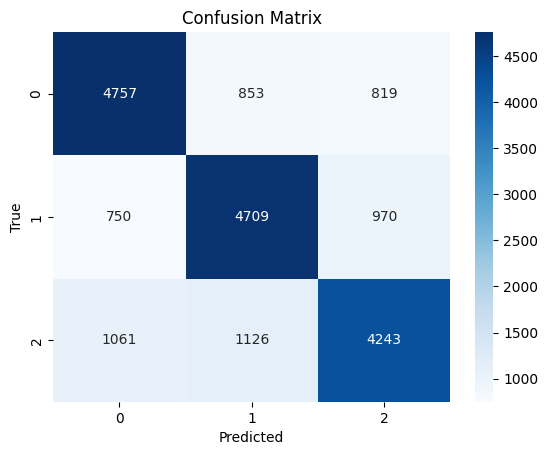

Macro-average F1 Score: 0.710321570416613


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_hat_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_classes), yticklabels=range(n_classes))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# F1 Score (Macro average)
f1_macro = f1_score(y_test, y_hat_classes, average='macro')
print(f'Macro-average F1 Score: {f1_macro}')

Key Points in the Confusion Matrix:

1. **Axes:**
   - The rows represent the **true class** labels (actual values in the test set).
   - The columns represent the **predicted class** labels (what the model predicted).

2. **Diagonal Cells:**
   - The diagonal cells (top-left to bottom-right) represent correct predictions (true positives for each class).
   - Higher values here indicate good performance for that class.

3. **Off-Diagonal Cells:**
   - The off-diagonal cells represent misclassifications:
     - For example, the cell at row 0 and column 1 (853) shows the number of samples of **class 0** that were incorrectly predicted as **class 1**.







Breakdown of the Matrix:

**Class 0 (Row 0):**
   - **True Positives**: 4757 (correctly classified as class 0).
   - **Misclassified as class 1**: 853.
   - **Misclassified as class 2**: 819.
   - The model struggles a bit with distinguishing class 0 from classes 1 and 2.

**Class 1 (Row 1):**
   - **True Positives**: 4709 (correctly classified as class 1).
   - **Misclassified as class 0**: 750.
   - **Misclassified as class 2**: 970.
   - Class 1 has relatively good performance but shows some confusion with class 2.

**Class 2 (Row 2):**
   - **True Positives**: 4243 (correctly classified as class 2).
   - **Misclassified as class 0**: 1061.
   - **Misclassified as class 1**: 1126.
   - Class 2 has the lowest true positives, indicating it is the most challenging class for the model to predict.

Macro-Average F1 Score: 0.7103
- The macro-average F1 score is provided at the bottom of the figure. This metric is the unweighted average of the F1-scores across all classes.
- A score of 0.71 aligns with the earlier evaluation, indicating the model's overall balanced but moderate performance.

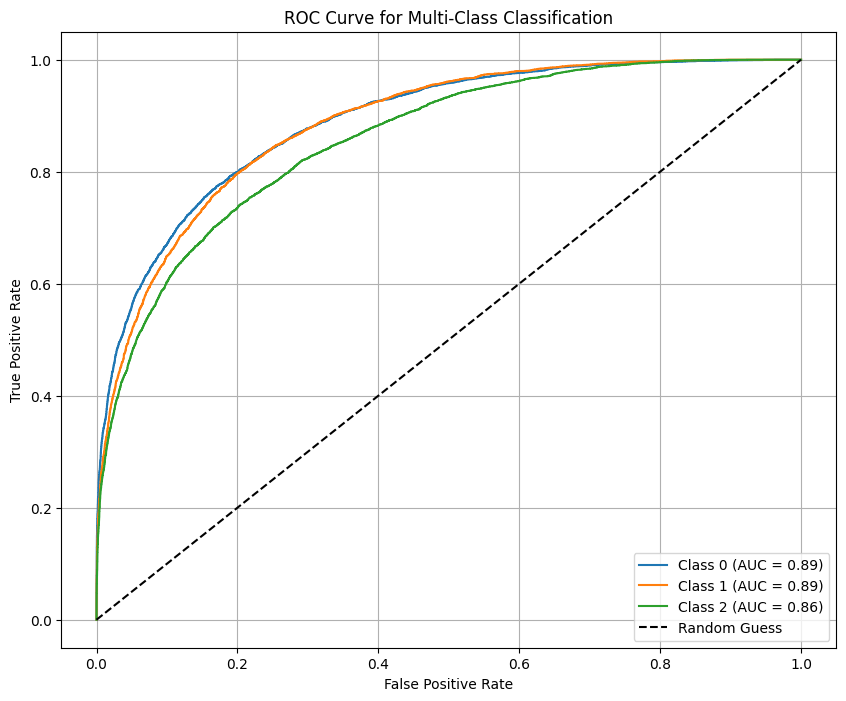

In [ ]:
# Ensure y_test_one_hot and y_hat are correctly formatted
# y_test_one_hot: One-hot encoded true labels
# y_hat: Predicted probabilities for each class

# Initialize a plot for ROC curves
plt.figure(figsize=(10, 8))

# Iterate over each class to plot its ROC curve
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_hat[:, i])  # Get FPR and TPR
    roc_auc = auc(fpr, tpr)  # Calculate AUC
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')  # Plot each curve

# Plot the diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Components of the Plot:
1. **True Positive Rate (y-axis)**:
   - Also known as **sensitivity** or **recall**.
   - Represents the proportion of actual positives that are correctly identified by the model.

2. **False Positive Rate (x-axis)**:
   - Represents the proportion of actual negatives that are incorrectly classified as positives.

3. **Curves for Each Class**:
   - Each curve corresponds to the performance of the model for one specific class (using a one-vs-rest approach).
   - The curves show how the trade-off between true positives and false positives changes as the decision threshold varies.

4. **AUC (Area Under the Curve)**:
   - AUC quantifies the overall performance of the model for each class.
   - Higher AUC values (closer to 1) indicate better model performance in distinguishing between classes.
   - Here:
     - Class 0: AUC = 0.89
     - Class 1: AUC = 0.89
     - Class 2: AUC = 0.86
   - The AUC values suggest the model performs slightly worse for **class 2** compared to classes 0 and 1.

5. **Random Guess Line (dashed line)**:
   - Represents the baseline performance of a random classifier (AUC = 0.5).
   - All curves above this line indicate that the model performs better than random guessing.

Observations:
1. **Strong Model Performance**:
   - All curves are significantly above the random guess line, showing that the model has good discriminative ability for all classes.
   - AUC values of 0.89 and 0.86 indicate solid performance.

2. **Class-Specific Differences**:
   - The model performs slightly worse for **class 2** (AUC = 0.86) compared to the other two classes (AUC = 0.89 for classes 0 and 1).
   - This aligns with earlier findings from the confusion matrix, where **class 2** had more misclassifications.

3. **Balanced Performance**:
   - The curves are fairly close together, suggesting the model does not heavily favor one class over another.


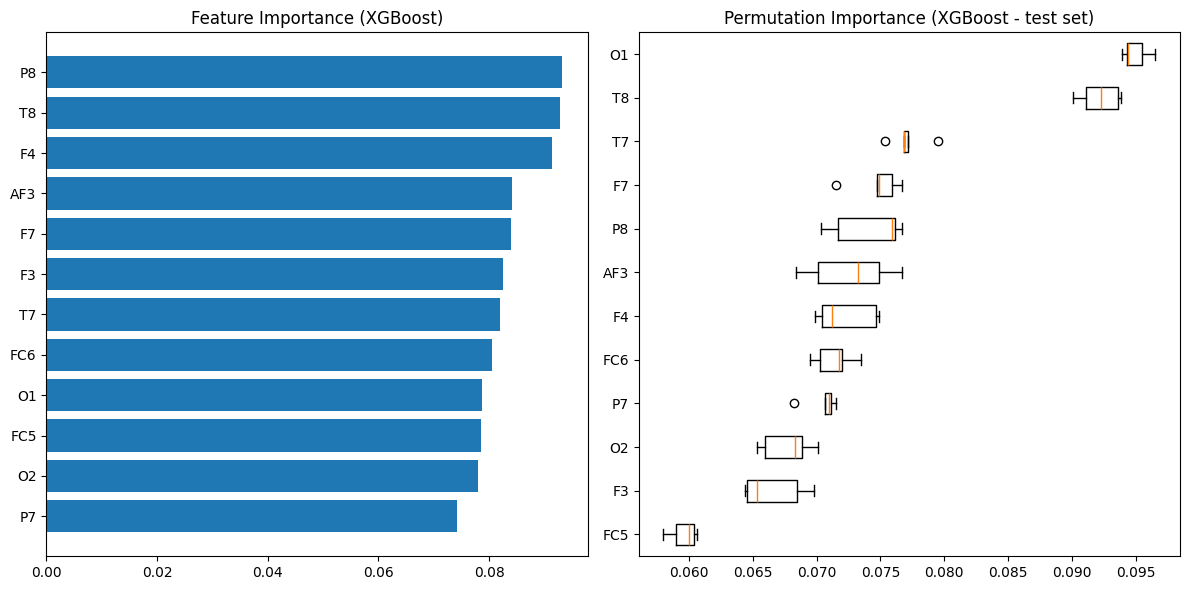

In [ ]:
fig = plt.figure(figsize=(12, 6))

# Feature Importance (using XGBoost's built-in feature importance)
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5

plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(data.columns.drop('state'))[sorted_idx])  # Replace with your feature names
plt.title("Feature Importance (XGBoost)")

# Permutation Importance
result = permutation_importance(
    model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=3
)
sorted_idx = result.importances_mean.argsort()

plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(data.columns.drop('state'))[sorted_idx],  # Replace with your feature names
)
plt.title("Permutation Importance (XGBoost - test set)")

fig.tight_layout()
plt.show()

This image contains two subplots that represent feature importance for a dataset analyzed using an XGBoost model. The subplots show:

- Feature Importance (XGBoost): This is a bar chart showing the importance of features based on the XGBoost model's internal metrics (e.g., gain, split count, or weight).

- Permutation Importance (XGBoost - test set): This is a box plot illustrating the permutation importance of features on the test set, reflecting how much shuffling each feature affects the model's performance.
Left Chart: Feature Importance (XGBoost)



Left Chart: Feature Importance (XGBoost)


What it represents:

- This chart shows the relative importance of each feature as calculated by the XGBoost model during training.

Observations:

- The features P8, T8, and F4 have the highest importance, as indicated by their longer bars. These features contribute significantly to the decision-making of the model.
Features like FC5, O2, and P7 have lower importance, indicating they were less useful for the model's predictions.
Implications:

- This model relies heavily on certain features like P8 and T8, which might indicate these features are strongly correlated with the target variable.

- Less important features might be candidates for removal or reduction during feature engineering to simplify the model.

Right Chart: Permutation Importance (XGBoost - test set)

What it represents:

- This chart shows the permutation importance of features. It measures the impact on model performance when a feature's values are randomly shuffled.
The box plot indicates the distribution of importance values across multiple shuffles, capturing variability.

Observations:

- Features like O1, T8, and T7 have the highest permutation importance. These features significantly impact the model's predictive ability on the test set.

- Features like P8, AF3, and F4, while important in the training feature importance chart, have a lower permutation importance. This suggests they may not generalize as well to unseen data.

- Features such as FC5 have consistently low importance, as reflected by their low box plot position.

Implications:

High permutation importance for features like O1 and T8 implies that these features are essential for the model's performance on unseen data.
Features with high variability in the box plot (e.g., P8, T8) might have unstable contributions and could benefit from further investigation or feature transformations.

Comparison Between Charts

Key Differences:

- In the left chart, features like P8 and T8 have high importance during training but are not as prominent in the permutation importance test (right chart). This could indicate overfitting, where these features are more useful for training but less so for generalization.

- Conversely, features like O1, which have lower training importance, are highly significant on the test set. This suggests they are robust and reliable for prediction.




Conclusion
While some features like P8 are influential during training, others like O1 are more impactful for generalization. Balancing these insights can improve the model's predictive accuracy and robustness.

## XGBoost on Data with Added Features

### Import data

In [ ]:
miraikawai_fft_features_path = kagglehub.dataset_download('miraikawai/fft-features')

print('Data source import complete.')


100%|██████████| 162M/162M [00:01<00:00, 91.3MB/s]

Extracting files...


Data source import complete.


In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
!ls $miraikawai_fft_features_path

Person_1.csv  Person_2.csv  Person_3.csv  Person_4.csv	Person_5.csv


In [ ]:
# Path to your directory
directory_path = miraikawai_fft_features_path

# Use glob to get all CSV files in the directory
file_paths = glob.glob(f"{directory_path}/*.csv")

# Read and concatenate all files
data_frames = [pd.read_csv(file) for file in file_paths]
data = pd.concat(data_frames, ignore_index=True)

### Basic information about data

In [ ]:
# Display the combined DataFrame
print(data)

       Unnamed: 0      F7_alpha       F7_beta      F7_theta      F7_delta  \
0               0  2.019564e+06  6.240262e+06  9.766144e+05  3.517040e+06   
1               1  2.492632e+06  5.460677e+06  1.232390e+06  2.950267e+06   
2               2  1.988606e+06  5.203172e+06  8.243734e+05  1.262590e+06   
3               3  2.060999e+06  4.743702e+06  2.403329e+06  2.835741e+06   
4               4  4.443342e+06  4.493957e+06  1.502904e+06  3.938372e+06   
...           ...           ...           ...           ...           ...   
77013       14968  2.238678e+06  5.404367e+06  3.436808e+06  3.143167e+06   
77014       14969  3.717173e+06  5.929175e+06  1.385599e+06  1.182567e+06   
77015       14970  3.937617e+06  5.371593e+06  4.939543e+06  5.759510e+06   
77016       14971  2.914715e+06  6.227182e+06  5.305246e+06  2.871356e+06   
77017       14972  1.602605e+06  5.310265e+06  1.280913e+06  4.400732e+06   

            F7_mean   F7_variance        F7_std     F7_energy  F7_skewness 

In [ ]:
# Remove "Unnamed" column
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

In [ ]:
print(data)

           F7_alpha       F7_beta      F7_theta      F7_delta       F7_mean  \
0      2.019564e+06  6.240262e+06  9.766144e+05  3.517040e+06 -1.439607e+06   
1      2.492632e+06  5.460677e+06  1.232390e+06  2.950267e+06 -8.494304e+04   
2      1.988606e+06  5.203172e+06  8.243734e+05  1.262590e+06 -1.017136e+06   
3      2.060999e+06  4.743702e+06  2.403329e+06  2.835741e+06  1.126675e+06   
4      4.443342e+06  4.493957e+06  1.502904e+06  3.938372e+06  1.715669e+06   
...             ...           ...           ...           ...           ...   
77013  2.238678e+06  5.404367e+06  3.436808e+06  3.143167e+06  1.684380e+05   
77014  3.717173e+06  5.929175e+06  1.385599e+06  1.182567e+06 -1.651016e+06   
77015  3.937617e+06  5.371593e+06  4.939543e+06  5.759510e+06  2.203437e+05   
77016  2.914715e+06  6.227182e+06  5.305246e+06  2.871356e+06  3.999747e+02   
77017  1.602605e+06  5.310265e+06  1.280913e+06  4.400732e+06 -3.367641e+05   

        F7_variance        F7_std     F7_energy  F7

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77018 entries, 0 to 77017
Columns: 241 entries, F7_alpha to state
dtypes: float64(240), int64(1)
memory usage: 141.6 MB


In [ ]:
data.head()

,F7_alpha,F7_beta,F7_theta,F7_delta,F7_mean,F7_variance,F7_std,F7_energy,F7_skewness,F7_kurtosis,...,F8_entropy,F8_cwt_scale_1,F8_cwt_scale_2,F8_cwt_scale_3,F8_cwt_scale_4,F8_cwt_scale_5,F8_cwt_scale_6,F8_cwt_scale_7,F8_cwt_scale_8,state
0,2.019564e+06,6.240262e+06,9.766144e+05,3.517040e+06,-1.439607e+06,2.889108e+13,5.375043e+06,3.963335e+15,0.116025,-0.825722,...,4.969311,240315.382290,386986.545991,9.844163e+05,1.298300e+06,1.288017e+06,1.450194e+06,1.363207e+06,1.378921e+06,0
1,2.492632e+06,5.460677e+06,1.232390e+06,2.950267e+06,-8.494304e+04,2.146412e+13,4.632939e+06,2.748331e+15,-0.139809,-0.354622,...,4.775157,263594.351746,397955.708838,1.153358e+06,1.145545e+06,1.297568e+06,1.290384e+06,1.508681e+06,1.696827e+06,0
2,1.988606e+06,5.203172e+06,8.243734e+05,1.262590e+06,-1.017136e+06,1.232204e+13,3.510276e+06,1.709645e+15,-0.448870,0.184537,...,4.806995,205688.349496,312558.246240,9.096787e+05,8.722772e+05,8.605585e+05,1.115224e+06,1.253758e+06,1.366726e+06,0
3,2.060999e+06,4.743702e+06,2.403329e+06,2.835741e+06,1.126675e+06,2.630131e+13,5.128481e+06,3.529051e+15,0.537868,0.515378,...,4.643967,316885.857417,416438.633404,1.402061e+06,1.273365e+06,1.357673e+06,1.902725e+06,2.067492e+06,1.875586e+06,0
4,4.443342e+06,4.493957e+06,1.502904e+06,3.938372e+06,1.715669e+06,3.512644e+13,5.926756e+06,4.872954e+15,0.253685,-0.197599,...,4.698355,513120.233843,643280.376992,2.314447e+06,1.984203e+06,1.892672e+06,2.337084e+06,2.426204e+06,1.894639e+06,0


In [ ]:
data.describe()

,F7_alpha,F7_beta,F7_theta,F7_delta,F7_mean,F7_variance,F7_std,F7_energy,F7_skewness,F7_kurtosis,...,F8_entropy,F8_cwt_scale_1,F8_cwt_scale_2,F8_cwt_scale_3,F8_cwt_scale_4,F8_cwt_scale_5,F8_cwt_scale_6,F8_cwt_scale_7,F8_cwt_scale_8,state
count,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,77018.000000,77018.000000,...,77018.000000,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,7.701800e+04,77018.000000
mean,3.130376e+06,4.126713e+06,1.902193e+06,3.664366e+06,4.631611e+03,4.323082e+13,5.480282e+06,5.933064e+15,-0.000162,-0.017329,...,4.480602,2.058211e+05,2.883451e+05,8.799804e+05,8.589441e+05,8.628582e+05,9.298303e+05,9.973613e+05,1.058593e+06,1.204303
std,2.665308e+06,2.031076e+06,1.389352e+06,3.087878e+06,1.766708e+06,1.140553e+14,3.632837e+06,1.639113e+16,0.441958,0.953677,...,0.679233,1.677366e+05,2.264797e+05,7.066955e+05,7.258388e+05,7.669720e+05,8.436616e+05,9.154047e+05,9.965579e+05,0.832805
min,5.266921e+04,1.561527e+05,2.478606e+04,2.607709e+04,-7.083209e+07,2.160840e+10,1.469980e+05,3.260470e+12,-3.942779,-1.721161,...,0.369057,2.009184e+02,2.185382e+02,8.022299e+02,7.675600e+02,1.061793e+03,1.113637e+03,9.406657e+02,1.045125e+03,0.000000
25%,1.394938e+06,2.708311e+06,9.123774e+05,1.531680e+06,-5.484963e+05,7.998678e+12,2.828193e+06,1.065234e+15,-0.237847,-0.497005,...,4.335261,6.545182e+04,9.101554e+04,2.879754e+05,2.898340e+05,2.778480e+05,3.137498e+05,3.639270e+05,4.153792e+05,0.000000
50%,2.348407e+06,4.096292e+06,1.597902e+06,2.973844e+06,-1.473236e+03,2.475397e+13,4.975336e+06,3.370056e+15,0.002983,-0.191770,...,4.745075,1.809931e+05,2.571439e+05,7.828415e+05,7.557564e+05,7.493803e+05,8.047888e+05,8.539298e+05,8.867501e+05,1.000000
75%,4.043877e+06,5.411672e+06,2.551397e+06,5.034553e+06,5.539153e+05,5.306905e+13,7.284851e+06,7.184681e+15,0.242836,0.211473,...,4.894025,3.122654e+05,4.469314e+05,1.335350e+06,1.246936e+06,1.220322e+06,1.276544e+06,1.330070e+06,1.375995e+06,2.000000
max,2.756428e+07,4.065690e+07,5.079454e+07,1.239956e+08,3.208965e+07,1.794814e+16,1.339707e+08,2.301560e+18,5.124953,34.517488,...,5.899557,2.591963e+06,3.566822e+06,1.152596e+07,1.410437e+07,1.533206e+07,1.864470e+07,1.972830e+07,2.185981e+07,2.000000


### Handle data imbalance

#### Visualize data imbalance

In [ ]:
# Group by the 'State' column and count occurrences
state_counts = data['state'].value_counts()

# Calculate percentages
state_percentages = (state_counts / len(data)) * 100

# Combine counts and percentages into a single DataFrame for easy viewing
state_distribution = pd.DataFrame({
    'Count': state_counts,
    'Percentage': state_percentages
})

# Print the distribution
print(state_distribution)

       Count  Percentage
state                   
2      36183   46.979927
0      20448   26.549638
1      20387   26.470435


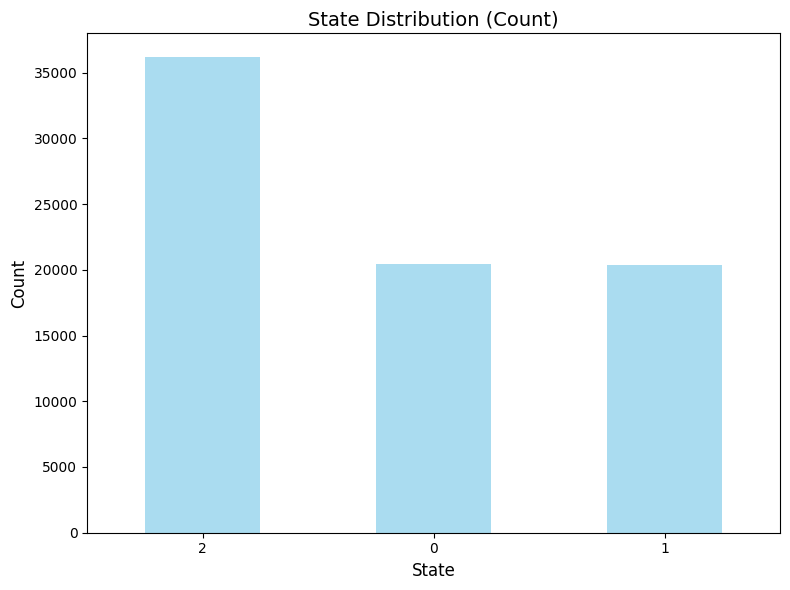

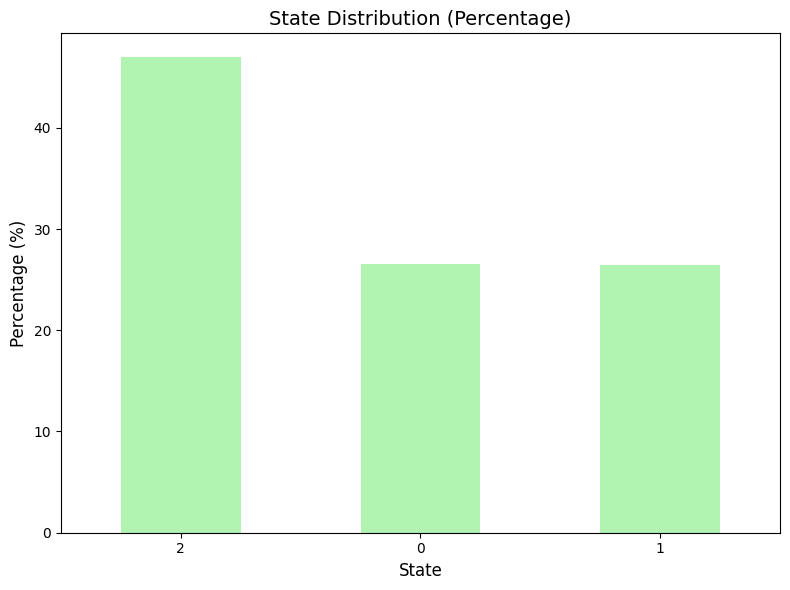

In [ ]:
# Combine counts and percentages into a single DataFrame for easy viewing
state_distribution = pd.DataFrame({
    'Count': state_counts,
    'Percentage': state_percentages
})

# Visualize the state distribution (count)
plt.figure(figsize=(8, 6))
state_counts.plot(kind='bar', color='skyblue', alpha=0.7)
plt.title('State Distribution (Count)', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Downsampling and SMOTE

In [ ]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# Features and target
X = data.drop(columns=['state'])  # Features
y = data['state']                 # Target variable

# Combine X and y into a single DataFrame for easier handling
combined_data = pd.concat([X, y], axis=1)

# Separate majority and minority classes
majority_class = combined_data[combined_data['state'] == 0]
minority_classes = combined_data[combined_data['state'] != 0]

# Determine 1.5x the largest minority class size
largest_minority_class_size = minority_classes['state'].value_counts().max()
downsampled_majority_size = int(1.5 * largest_minority_class_size)

# Determine the downsample size, ensuring it's no larger than the available majority class size
downsampled_majority_size = min(int(1.5 * largest_minority_class_size), len(majority_class))

# Downsample the majority class
majority_downsampled = resample(
    majority_class,
    replace=False,  # Sampling without replacement
    n_samples=downsampled_majority_size,
    random_state=42
)

# Combine the downsampled majority class with minority classes
downsampled_data = pd.concat([majority_downsampled, minority_classes])

# Split features and target again
X_downsampled = downsampled_data.drop(columns=['state'])
y_downsampled = downsampled_data['state']

# Print class distribution after downsampling
print("Class distribution after downsampling:", Counter(y_downsampled))

# Apply SMOTE on the downsampled dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_downsampled, y_downsampled)

# Print class distribution after SMOTE
print("Class distribution after SMOTE:", Counter(y_resampled))

# Combine resampled features and target into a single DataFrame if needed
resampled_data = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=['state'])], axis=1)


Class distribution after downsampling: Counter({2: 36183, 0: 20448, 1: 20387})
Class distribution after SMOTE: Counter({0: 36183, 1: 36183, 2: 36183})


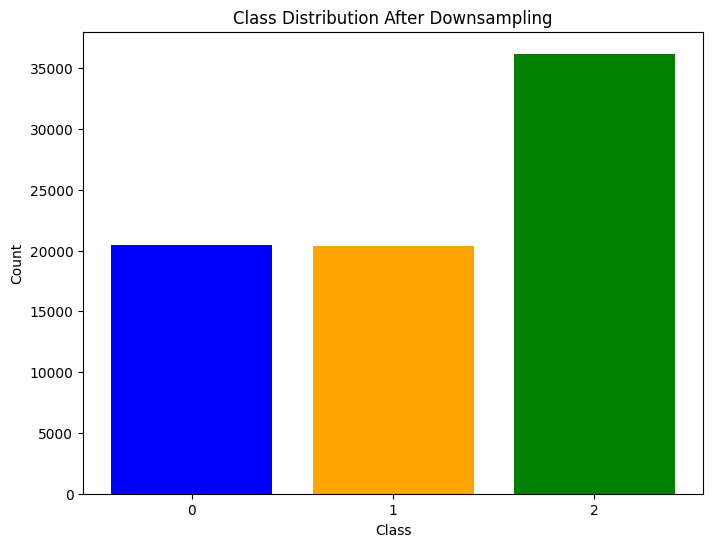

In [ ]:
# Histogram for downsampled data
plt.figure(figsize=(8, 6))
plt.bar(Counter(y_downsampled).keys(), Counter(y_downsampled).values(), color=['blue', 'orange', 'green'])
plt.title("Class Distribution After Downsampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(list(Counter(y_downsampled).keys()))
plt.show()


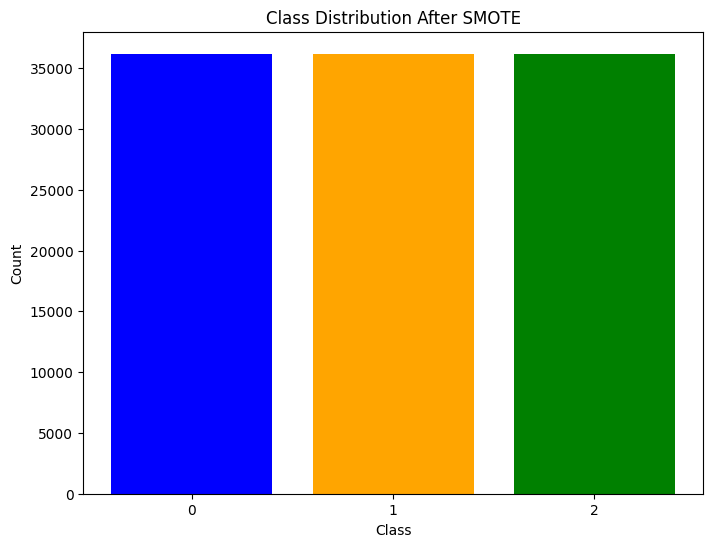

In [ ]:
# Histogram for SMOTE resampled data
plt.figure(figsize=(8, 6))
plt.bar(Counter(y_resampled).keys(), Counter(y_resampled).values(), color=['blue', 'orange', 'green'])
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(list(Counter(y_resampled).keys()))
plt.show()

### Split data

In [ ]:
# Split into 80% training/validation and 20% test based on 'state'
train_val, test = train_test_split(
    resampled_data, test_size=0.2, stratify=resampled_data['state'], random_state=42
)

# Further split training/validation into 80% training and 20% validation
train, val = train_test_split(
    train_val, test_size=0.2, stratify=train_val['state'], random_state=42
)

# Verify the splits (optional)
train_percentage = len(train) / len(resampled_data) * 100
val_percentage = len(val) / len(resampled_data) * 100
test_percentage = len(test) / len(resampled_data) * 100

print(f"Train: {len(train)} ({train_percentage:.2f}%)")
print(f"Validation: {len(val)} ({val_percentage:.2f}%)")
print(f"Test: {len(test)} ({test_percentage:.2f}%)")

Train: 69471 (64.00%)
Validation: 17368 (16.00%)
Test: 21710 (20.00%)


In [ ]:
# Prepare Features and Target
X_train = train.drop(columns=['state'])
y_train = train['state']

X_val = val.drop(columns=['state'])
y_val = val['state']

X_test = test.drop(columns=['state'])
y_test = test['state']

### Train model

Configuration for the following model is the same as the model in the previous section, except for parameter 'n_estimators' is reduced to 2000 from 3000 in order to speed up the training process on this dataset, due to the fact that it is larger than the other dataset.

In [ ]:
# Prepare Features and Target
# Define the XGBoost model
model = XGBClassifier(
    objective="multi:softmax",  # Objective function for multi-class classification
    num_class=data['state'].nunique(),  # Number of unique classes in the target
    learning_rate=0.05,         # Learning rate for gradient boosting
    n_estimators=2000,          # Maximum number of boosting iterations
    max_depth=4,                # Maximum depth of each tree
    subsample=0.8,              # Fraction of samples used for training each tree
    colsample_bytree=0.8,       # Fraction of features used for training each tree
    early_stopping_rounds=100,  # Stops training if validation score doesn't improve
    random_state=42,            # For reproducibility
    verbosity=1                 # Controls the level of output during training
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],  # Training and validation sets
    verbose=50  # Log progress every 50 rounds
)

[0]	validation_0-mlogloss:1.08553	validation_1-mlogloss:1.08569
[50]	validation_0-mlogloss:0.81781	validation_1-mlogloss:0.82255
[100]	validation_0-mlogloss:0.71986	validation_1-mlogloss:0.72998
[150]	validation_0-mlogloss:0.65608	validation_1-mlogloss:0.67163
[200]	validation_0-mlogloss:0.60962	validation_1-mlogloss:0.62999
[250]	validation_0-mlogloss:0.57063	validation_1-mlogloss:0.59530
[300]	validation_0-mlogloss:0.53871	validation_1-mlogloss:0.56702
[350]	validation_0-mlogloss:0.51232	validation_1-mlogloss:0.54458
[400]	validation_0-mlogloss:0.48871	validation_1-mlogloss:0.52500
[450]	validation_0-mlogloss:0.46763	validation_1-mlogloss:0.50756
[500]	validation_0-mlogloss:0.44809	validation_1-mlogloss:0.49153
[550]	validation_0-mlogloss:0.43179	validation_1-mlogloss:0.47847
[600]	validation_0-mlogloss:0.41498	validation_1-mlogloss:0.46508
[650]	validation_0-mlogloss:0.40066	validation_1-mlogloss:0.45375
[700]	validation_0-mlogloss:0.38710	validation_1-mlogloss:0.44328
[750]	validat

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

Results

1. **Starting High Log Loss**
   - At iteration 0, the log loss is around `1.08553` for training and `1.08569` for validation. This high loss at the beginning is expected as the model starts without any optimization (random initialization).

2. **Gradual Decrease in Log Loss**
   - Over the iterations, the log loss for both training and validation sets decreases significantly. For instance:
     - By iteration 100: Training loss = `0.71986`, Validation loss = `0.72998`.
     - By iteration 1000: Training loss = `0.32107`, Validation loss = `0.39406`.
     - By iteration 1999: Training loss = `0.19267`, Validation loss = `0.30692`.
   - This demonstrates the model is fitting the training data and improving on the validation set.

3. **No Early Stopping Triggered**
   - The training continued for the full 2000 iterations, implying that the validation loss kept improving (no plateau or overfitting detected).

4. **Validation Loss Higher Than Training Loss**
   - The validation loss is slightly higher than the training loss throughout the process, which is typical and expected due to the model's exposure to training data and its inability to see the validation data during training.

Analysis

1. **Improvement in Validation Loss**
   - The validation loss reduction from `1.08569` to `0.30692` shows the model learned patterns from the training data and applied them well to the validation data.

2. **Small Gap Between Training and Validation Loss**
   - The gap between training and validation loss reduces as training progresses. This suggests the model achieves better generalization, likely due to the choice of regularization parameters (e.g., subsampling and feature sampling).

3. **Key Observations**
   - The validation loss decreasing steadily indicates:
     - No early plateau or divergence (which would indicate underfitting or overfitting).
     - The dataset's features are likely informative for the target variable.
     - There may still be room for improvement in the loss values if fine-tuned hyperparameters or additional data transformations are applied.

### Model evaluation

In [ ]:
# Evaluate the model
# Validation
y_val_pred = model.predict(X_val)  # Predict classes for validation data
val_accuracy = accuracy_score(y_val, y_val_pred)  # Calculate accuracy
print(f"Validation Accuracy: {val_accuracy:.2f}")

# Test
y_test_pred = model.predict(X_test)  # Predict classes for test data
test_accuracy = accuracy_score(y_test, y_test_pred)  # Calculate accuracy
print(f"Test Accuracy: {test_accuracy:.2f}")

Validation Accuracy: 0.89
Test Accuracy: 0.89


In [ ]:
# Predict probabilities
y_hat = model.predict_proba(X_test)  # Predict probabilities for each class

# Convert probabilities to class labels
y_hat_classes = np.argmax(y_hat, axis=1)

# One-hot encode the labels for AUC calculation
n_classes = y_hat.shape[1]  # Number of classes
y_test_one_hot = label_binarize(y_test, classes=range(n_classes))

# Calculate AUC (OvR strategy)
auc_scores = roc_auc_score(y_test_one_hot, y_hat, average=None, multi_class='ovr')
macro_auc = roc_auc_score(y_test_one_hot, y_hat, average='macro', multi_class='ovr')

# Print evaluation metrics
print('Evaluation on test set:')
print(classification_report(y_test, y_hat_classes))
print(f'Class-wise AUC scores: {auc_scores}')
print(f'Macro-average AUC: {macro_auc}')

Evaluation on test set:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      7236
           1       0.85      0.85      0.85      7237
           2       0.91      0.92      0.92      7237

    accuracy                           0.89     21710
   macro avg       0.89      0.89      0.89     21710
weighted avg       0.89      0.89      0.89     21710

Class-wise AUC scores: [0.97880822 0.9624737  0.98568444]
Macro-average AUC: 0.9756554517380542


**Metrics Overview**

1. **Precision**
   - Class `0`: 0.90
   - Class `1`: 0.85
   - Class `2`: 0.91
   - **Interpretation**:
     - Precision indicates the proportion of predicted positives for a class that are actually correct.
     - Class `2` has the highest precision, suggesting that the model is least likely to produce false positives for this class.
     - Class `1` has the lowest precision, indicating relatively more false positives.

2. **Recall**
   - Class `0`: 0.89
   - Class `1`: 0.85
   - Class `2`: 0.92
   - **Interpretation**:
     - Recall (sensitivity) indicates the proportion of actual positives for a class that are correctly identified.
     - Class `2` has the highest recall, meaning the model captures most of the true positives for this class.
     - Class `1` has the lowest recall, indicating some true positives for this class are missed.

3. **F1-Score**
   - Class `0`: 0.89
   - Class `1`: 0.85
   - Class `2`: 0.92
   - **Interpretation**:
     - The F1-score is the harmonic mean of precision and recall, balancing the two metrics.
     - Class `2` has the best F1-score, showing strong performance in both precision and recall.
     - Class `1` has the lowest F1-score, suggesting room for improvement.

4. **Support**
   - Each class has equal support: 7236 samples for classes `0`, `1`, and `2`.
   - **Interpretation**: The balanced support ensures that performance metrics are not biased by an imbalanced dataset.

5. **Accuracy**
   - **Value**: 0.89
   - **Interpretation**: The model correctly predicts the class for 89% of the samples in the test set.

6. **Macro Average**
   - **Precision, Recall, F1-Score**: All equal to 0.89.
   - **Interpretation**: The macro-average equally weights each class when calculating metrics, regardless of their support. Here, all metrics align due to balanced class support.

7. **Weighted Average**
   - **Precision, Recall, F1-Score**: All equal to 0.89.
   - **Interpretation**: The weighted average takes class support into account, but since the dataset is balanced, the weighted averages match the macro averages.

8. **AUC Scores**
   - **Class-wise AUC**: `[0.9788, 0.9624, 0.9856]`
   - **Macro-average AUC**: `0.9756`
   - **Interpretation**:
     - AUC measures the ability of the model to distinguish between classes. Values close to 1 indicate excellent performance.
     - Class `2` has the highest AUC (`0.9856`), meaning the model is most effective at distinguishing this class from others.
     - Class `1` has the lowest AUC (`0.9624`), but the performance is still strong.




**Strengths**

1. **High Overall Performance**
   - The model achieves high precision, recall, and F1-scores across all classes, with no significant drop in performance for any class.

2. **Balanced Metrics**
   - Metrics like macro and weighted averages are consistent, indicating a well-balanced model performance across classes.

3. **Excellent AUC**
   - AUC values above 0.96 for all classes show the model excels at distinguishing between classes.

4. **Balanced Dataset**
   - Equal class support ensures the evaluation is unbiased and each class contributes equally to the metrics.

**Weaknesses**

1. **Class 1 Performance**
   - Class `1` has slightly lower precision (`0.85`), recall (`0.85`), and F1-score (`0.85`) compared to the other classes.
   - Suggests the model might struggle to correctly classify samples from Class `1`.

2. **Room for Improvement in Precision**
   - Precision for Class `1` and Class `0` is slightly lower than for Class `2`. Improving this would reduce false positives for these classes.

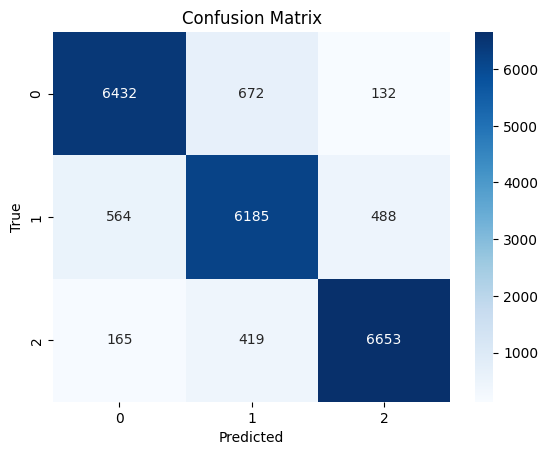

Macro-average F1 Score: 0.8876271693948641


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_hat_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_classes), yticklabels=range(n_classes))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# F1 Score (Macro average)
f1_macro = f1_score(y_test, y_hat_classes, average='macro')
print(f'Macro-average F1 Score: {f1_macro}')

**Insights**

Class 0 (Top Row)

- True Positives (Correctly Predicted as 0): 6432
- False Negatives (Misclassified as 1 or 2): 804
  - Misclassified as 1: 672
  - Misclassified as 2: 132
    
- Key Observations:
  - Most predictions for Class 0 are correct.
  - The majority of errors occur when Class 0 is misclassified as Class 1, which suggests some overlap or confusion between these two classes in the model.

Class 1 (Middle Row)
- True Positives (Correctly Predicted as 1): 6185
- False Negatives (Misclassified as 0 or 2): 1052
  - Misclassified as 0: 564
  - Misclassified as 2: 488
- Key Observations:
  - While the model performs well on Class 1, there is noticeable confusion with Class 0 (564 cases) and Class 2 (488 cases).
  - This aligns with the slightly lower metrics for Class 1 (as observed in the classification report from your earlier screenshot).

Class 2 (Bottom Row)
- True Positives (Correctly Predicted as 2): 6653
- False Negatives (Misclassified as 0 or 1): 584
  - Misclassified as 0: 165
  - Misclassified as 1: 419
- Key Observations:
  - Class 2 has the least misclassifications overall, indicating that the model handles this class well.
  - The main source of error is misclassifying Class 2 as Class 1.

Macro-Average F1-Score
- Value: 0.8876
- Interpretation:
  - This score reflects a balanced performance across all classes, taking into account precision and recall equally for each class.
  - The model achieves a strong overall F1-score, but there’s room for slight improvement, particularly for Class 1.

Error Analysis
- Confusion Between Classes 0 and 1:
  - Class 0 is often confused with Class 1 (672 instances).
  - Class 1 is frequently misclassified as Class 0 (564 instances). This suggests shared features or overlapping boundaries in the data between these two classes.

- Confusion Between Classes 1 and 2:
  - Class 1 is misclassified as Class 2 (488 instances).
  - Class 2 is misclassified as Class 1 (419 instances). This indicates a secondary area of confusion that could be addressed similarly to the Class 0 and 1 case.

Key Strengths
- Strong Overall Performance:
  - The diagonal dominance of the confusion matrix shows that most predictions are correct.
  - Class 2, in particular, is predicted very accurately, with minimal misclassifications.
- High F1-Score: The macro-average F1-score of 0.8876 is indicative of a well-performing model.

**Summary**

The model achieves excellent overall performance, but there is noticeable confusion between specific class pairs, particularly Class 0 and Class 1. Addressing these misclassifications with targeted techniques could further boost the model’s effectiveness. The macro-average F1-score of 0.8876 demonstrates that the model is generally robust and balanced.

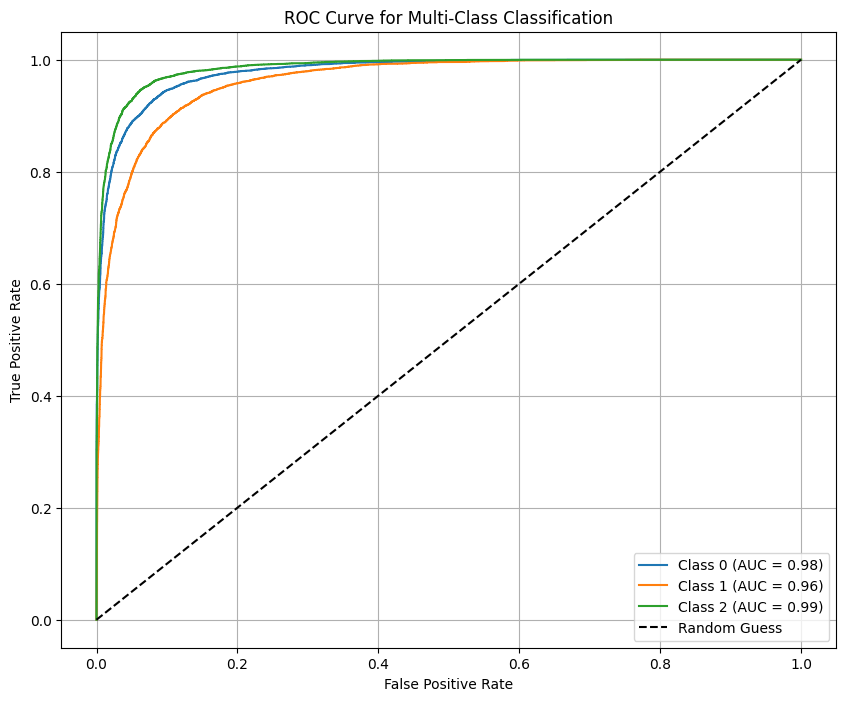

In [ ]:
# Ensure y_test_one_hot and y_hat are correctly formatted
# y_test_one_hot: One-hot encoded true labels
# y_hat: Predicted probabilities for each class

# Initialize a plot for ROC curves
plt.figure(figsize=(10, 8))

# Iterate over each class to plot its ROC curve
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_hat[:, i])  # Get FPR and TPR
    roc_auc = auc(fpr, tpr)  # Calculate AUC
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')  # Plot each curve

# Plot the diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc='lower right')
plt.grid()
plt.show()

**Key Observations**
1. **Overall Shape**:
   - All three curves (Classes 0, 1, and 2) are much closer to the top-left corner, indicating excellent classification performance. This means the model achieves a high TPR while maintaining a low FPR for each class.

2. **AUC Scores**:
   - **Class 0 (Blue Line)**: AUC = 0.98
     - This indicates that the model distinguishes Class 0 very well from the other classes.
   - **Class 1 (Orange Line)**: AUC = 0.96
     - Class 1 has a slightly lower AUC than the others, which aligns with the confusion matrix and classification report where Class 1 had the most errors (misclassified as Class 0 or Class 2).
   - **Class 2 (Green Line)**: AUC = 0.99
     - Class 2 achieves the highest AUC, indicating it is the easiest class for the model to identify.

3. **Random Guess Baseline (Black Dashed Line)**:
   - The dashed line represents the performance of a random classifier with an AUC of 0.5. All three curves are far above this baseline, confirming that the model significantly outperforms random guessing.


**Class-Level Insights**
1. **Class 0**:
   - Excellent discrimination between Class 0 and the other two classes (AUC = 0.98).
   - Minimal overlap with false positives, as indicated by the curve hugging the top-left corner.

2. **Class 1**:
   - AUC = 0.96, slightly lower than Class 0 and Class 2. This is consistent with the confusion matrix, where Class 1 exhibited more misclassifications.
   - The model struggles slightly more with distinguishing Class 1 from Classes 0 and 2 compared to the other classes.

3. **Class 2**:
   - AUC = 0.99, indicating near-perfect separation from other classes.
   - Consistent with the confusion matrix and classification report, where Class 2 had the fewest misclassifications.

**Model Strengths**
- **High Overall AUC**:
  - All classes have AUC values above 0.95, indicating that the model performs exceptionally well across all classes.
- **Good Class Balance**:
  - While Class 1 has a slightly lower AUC, it is still very high, demonstrating that the model is fairly balanced across the three classes.

**Summary**

This ROC analysis confirms the model's strong performance, with excellent AUC scores for all classes (0.96–0.99). Class 1 shows slightly weaker performance relative to Classes 0 and 2, but the difference is minor. To further improve, focus on understanding why Class 1 is more prone to misclassification and fine-tune the model accordingly.

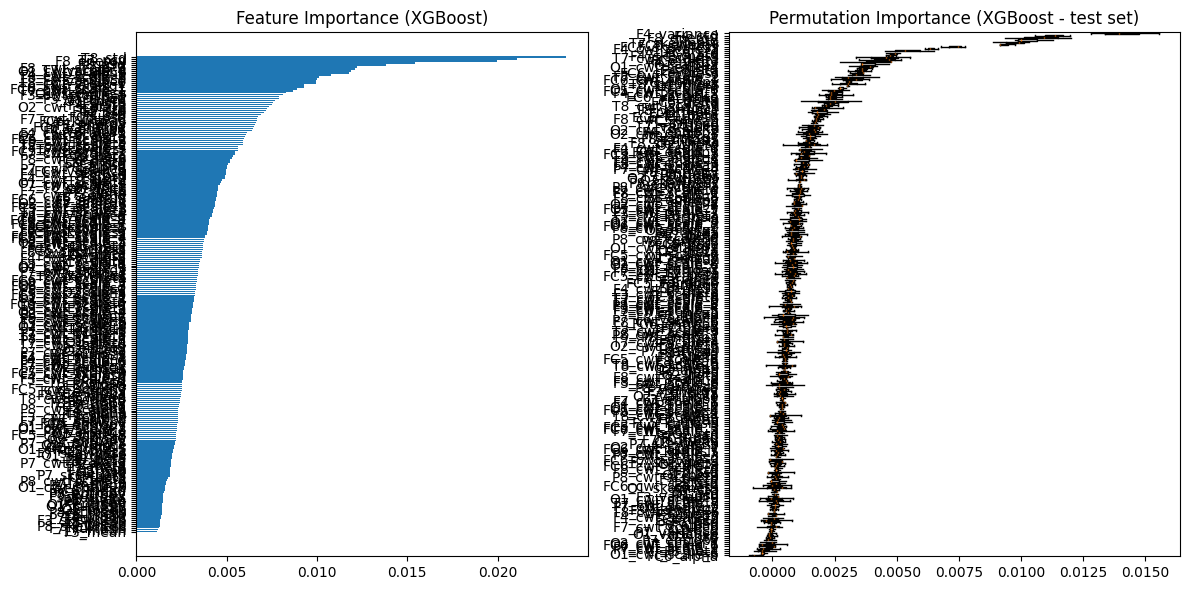

In [ ]:
fig = plt.figure(figsize=(12, 6))

# Feature Importance (using XGBoost's built-in feature importance)
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5

plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(data.columns.drop('state'))[sorted_idx])  # Replace with your feature names
plt.title("Feature Importance (XGBoost)")

# Permutation Importance
result = permutation_importance(
    model, X_test, y_test, n_repeats=3, random_state=42, n_jobs=3
)
sorted_idx = result.importances_mean.argsort()

plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(data.columns.drop('state'))[sorted_idx],  # Replace with your feature names
)
plt.title("Permutation Importance (XGBoost - test set)")

fig.tight_layout()
plt.show()

**Left Panel: Feature Importance (XGBoost)**
**Insights**:
   - The importance is skewed: A few features at the top have much higher importance, while many have negligible contributions.
   - This implies the model relies heavily on a small subset of features, which dominate the decision-making process.


**Right Panel: Permutation Importance (Test Set)**
1. **Interpretation**:
   - Permutation Importance evaluates the effect of randomly shuffling a feature's values on the model's performance.
   - Features that cause significant drops in performance when shuffled are more important.
   - Error bars represent variability in importance across multiple permutations or cross-validation folds.

2. **Insights**:
   - The importance distribution is narrower compared to the XGBoost-calculated importance, suggesting that while a few features are still more important, the relative contributions of other features are more evenly spread.
   - The error bars are small for most features, indicating consistent behavior across different data subsets.

3. **Comparison with Left Panel**:
   - Permutation Importance offers a more robust, model-agnostic view compared to the intrinsic XGBoost importance.
   - This might help identify features that are less biased by the tree-building process.


**General Observations**
1. **Feature Redundancy**:
   - If features ranked low in permutation importance appear high in the XGBoost chart, it could indicate redundancy (e.g., correlated features). You may want to investigate these further.

2. **Clarity of Feature Names**:
   - The cluttered Y-axis in both plots makes it hard to extract actionable information. Re-plotting with fewer top features or separating them into groups could improve interpretability.

**Summary**
- The left panel shows feature importance directly from the XGBoost model, highlighting a few dominant features.
- The right panel uses permutation importance, providing a more data-driven, robust assessment of feature contributions.
- To refine the analysis, focus on the top features in both charts, reduce dimensionality by excluding unimportant ones, and consider improving the plot’s readability.

For more clarity of the feature names, the top 20 important features and the top 20 features that have the most permutation importance are printed below.

In [ ]:
# Extract top 20 features from XGBoost's built-in importance
sorted_idx_xgb = np.argsort(feature_importance)[-20:]  # Indices of the top 20 features
top_features_xgb = np.array(data.columns.drop('state'))[sorted_idx_xgb]
top_importance_xgb = feature_importance[sorted_idx_xgb]

print("Top 20 Features (XGBoost built-in importance):")
for feature, importance in zip(top_features_xgb[::-1], top_importance_xgb[::-1]):
    print(f"{feature}: {importance}")

# Extract top 20 features from Permutation Importance
sorted_idx_perm = result.importances_mean.argsort()[-20:]
top_features_perm = np.array(data.columns.drop('state'))[sorted_idx_perm]
top_importance_perm = result.importances_mean[sorted_idx_perm]

print("\nTop 20 Features (Permutation Importance):")
for feature, importance in zip(top_features_perm[::-1], top_importance_perm[::-1]):
    print(f"{feature}: {importance}")

Top 20 Features (XGBoost built-in importance):
T8_std: 0.02379298210144043
T7_psd: 0.02109503746032715
F8_energy: 0.019977401942014694
F8_psd: 0.015430730767548084
F7_std: 0.013842443935573101
F8_cwt_scale_2: 0.0122184744104743
T7_variance: 0.012117554433643818
O1_cwt_scale_8: 0.011904779821634293
O1_alpha: 0.011769791133701801
F4_cwt_scale_1: 0.010793312452733517
T8_cwt_scale_8: 0.010097548365592957
F3_psd: 0.010011729784309864
F8_variance: 0.009964600205421448
F8_cwt_scale_1: 0.009944439865648746
FC6_energy: 0.009299888275563717
T8_cwt_scale_1: 0.009297393262386322
FC6_cwt_scale_1: 0.008903694339096546
T7_cwt_scale_1: 0.008655726909637451
O1_skewness: 0.008300081826746464
F3_cwt_scale_1: 0.008113120682537556

Top 20 Features (Permutation Importance):
F4_variance: 0.014110241056348912
F4_std: 0.011300475971134741
F8_energy: 0.010763089206203022
T8_std: 0.010348533701827164
T7_skewness: 0.009703669583909114
FC6_energy: 0.009365883617380666
FC5_skewness: 0.007323813910640298
F4_cwt_scal

Key Observations
Common Features Across Both Rankings:
- Some features are important in both rankings, indicating they are critical for the model:
  - F8_energy
  - T8_std
  - F4_cwt_scale_1
- These features have consistently high importance in both the XGBoost and permutation-based methods.

Differences in Rankings:
- Features prioritized by XGBoost Built-in Importance: T7_psd, F7_std, T7_variance, O1_cwt_scale_8, etc., appear high in the XGBoost ranking but do not show up as strongly in permutation importance. This might indicate they are structurally significant in the tree-building process (e.g., splits or gains) but have less impact on overall model performance.

Features prioritized by Permutation Importance:
- F4_variance, F4_std, F4_skewness, FC6_delta, etc., are highly ranked in permutation importance but are less prominent in XGBoost's intrinsic ranking. These features likely have strong predictive power in the dataset, even if not frequently used by the model’s tree structure.